In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/HDFCBANK.NS_stock_data.csv')

### Data Preprocessing

First, we need to clean and prepare the stock data. This involves converting the date column to the correct format, setting it as the DataFrame index, and calculating daily returns.

In [3]:
# Rename the first column to 'Date' and convert it to datetime objects
df = df.rename(columns={'Unnamed: 0': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index of the DataFrame
df = df.set_index('Date')

# Sort the DataFrame by Date
df = df.sort_index()

# Handle any potential missing values (e.g., forward fill or backward fill if appropriate for stock data)
df.fillna(method='ffill', inplace=True)

# Calculate Daily Returns
df['Daily_Return'] = df['close'].pct_change() * 100

# Extract time-based features for filtering and analysis
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['Day_of_Week'] = df.index.dayofweek # Monday=0, Sunday=6

print("DataFrame Info after preprocessing:")
df.info()

print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df.head())

DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7124 entries, 1996-01-01 to 2024-04-29
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          7124 non-null   float64
 1   high          7124 non-null   float64
 2   low           7124 non-null   float64
 3   close         7124 non-null   float64
 4   adjclose      7124 non-null   float64
 5   volume        7124 non-null   float64
 6   ticker        7124 non-null   object 
 7   Daily_Return  7123 non-null   float64
 8   Year          7124 non-null   int32  
 9   Month         7124 non-null   int32  
 10  Quarter       7124 non-null   int32  
 11  Day_of_Week   7124 non-null   int32  
dtypes: float64(7), int32(4), object(1)
memory usage: 612.2+ KB

First 5 rows of the preprocessed DataFrame:


/tmp/ipykernel_7664/2051119075.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,open,high,low,close,adjclose,volume,ticker,Daily_Return,Year,Month,Quarter,Day_of_Week
Date,,,,,,,,,,,,
1996-01-01,3.030,3.030,2.925,2.980,2.362861,350000.0,HDFCBANK.NS,NaN,1996,1,1,0
1996-01-02,2.980,3.025,2.950,2.975,2.358896,412000.0,HDFCBANK.NS,-0.167789,1996,1,1,1
1996-01-03,2.975,2.995,2.950,2.985,2.366825,284000.0,HDFCBANK.NS,0.336134,1996,1,1,2
1996-01-04,2.985,2.980,2.940,2.965,2.350967,282000.0,HDFCBANK.NS,-0.670016,1996,1,1,3
1996-01-05,2.965,2.980,2.950,2.960,2.347002,189000.0,HDFCBANK.NS,-0.168630,1996,1,1,4


### 1. Stock Performance Overview (KPI Cards)

Here we will calculate and display key performance indicators: Current Stock Price, 52 Week High, 52 Week Low, and Market Trend (daily percentage change).

In [4]:
# Current Stock Price (Last Closing Price)
current_price = df['close'].iloc[-1]

# 52 Week High and Low
# Ensure we have at least 252 trading days (approx. 52 weeks * 5 days/week) of data
if len(df) >= 252:
    df_last_52_weeks = df['close'].iloc[-252:]
    week_high_52 = df_last_52_weeks.max()
    week_low_52 = df_last_52_weeks.min()
else:
    # If less than 52 weeks of data, use available max/min
    week_high_52 = df['close'].max()
    week_low_52 = df['close'].min()

# Market Trend (% Change from previous day's close)
market_trend_percent = df['Daily_Return'].iloc[-1]

print(f"Current Stock Price: {current_price:.2f}")
print(f"52 Week High: {week_high_52:.2f}")
print(f"52 Week Low: {week_low_52:.2f}")
print(f"Market Trend (Last Day Change): {market_trend_percent:.2f}%")

Current Stock Price: 1529.50
52 Week High: 1728.20
52 Week Low: 1384.05
Market Trend (Last Day Change): 1.30%


### 2. Price Movement Charts

We will visualize the stock's price movement using a line chart for the closing price and a candlestick chart for Open, High, Low, and Close prices.

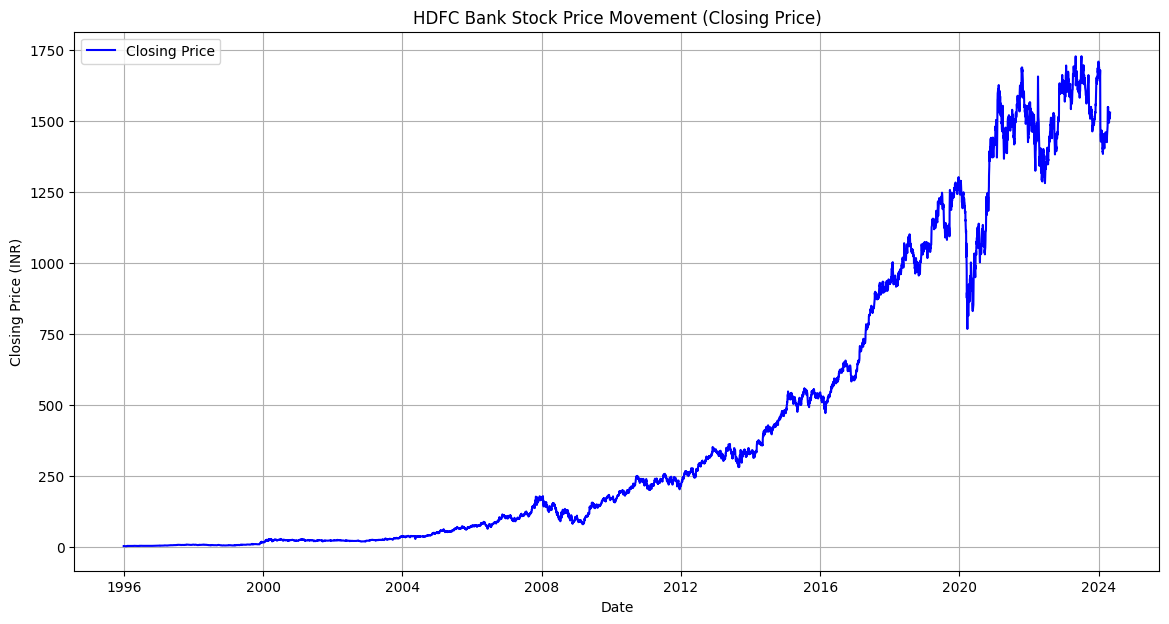

In [5]:
# Line chart for Closing Price
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close'], label='Closing Price', color='blue')
plt.title('HDFC Bank Stock Price Movement (Closing Price)')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.grid(True)
plt.legend()
plt.show()

#### Candlestick Chart

For a more detailed view of daily price movements (Open, High, Low, Close), we will use a candlestick chart. We might need to install the `mplfinance` library if it's not already available.

In [6]:
# Install mplfinance if not already installed
try:
    import mplfinance as mpf
except ImportError:
    %pip install mplfinance
    import mplfinance as mpf

# Prepare data for candlestick chart (mplfinance requires specific column names and index)
ohlc_df = df[['open', 'high', 'low', 'close', 'volume']]

# Plot candlestick chart for a recent period (e.g., last 6 months) to keep it readable
# You can adjust the `slice_date` to see different periods
slice_date = pd.Timestamp.now() - pd.DateOffset(months=6)
recent_ohlc = ohlc_df[ohlc_df.index >= slice_date]

if not recent_ohlc.empty:
    fig, axes = mpf.plot(recent_ohlc,
                         type='candle',
                         style='yahoo',
                         volume=True,
                         title='HDFC Bank Candlestick Chart (Last 6 Months)',
                         ylabel='Price (INR)',
                         ylabel_lower='Volume',
                         figscale=1.5,
                         returnfig=True)
    fig.show()
else:
    print("Not enough recent data to plot a candlestick chart for the last 6 months.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.8 MB/s eta 0:00:00
Not enough recent data to plot a candlestick chart for the last 6 months.


### 3. Moving Average Analysis for 365 days

We will calculate and plot the 365-day Simple Moving Average (SMA) to analyze long-term trends in the stock price.

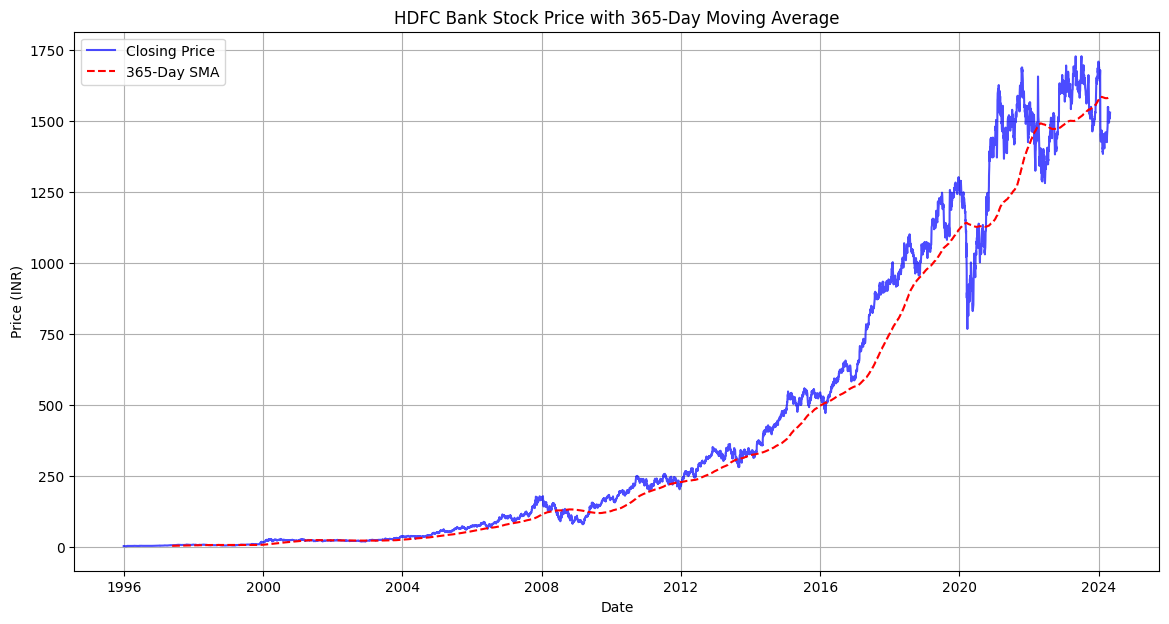

In [7]:
# Calculate 365-day Simple Moving Average (SMA)
df['SMA_365'] = df['close'].rolling(window=365).mean()

# Plotting the Closing Price and 365-day SMA
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['close'], label='Closing Price', color='blue', alpha=0.7)
plt.plot(df.index, df['SMA_365'], label='365-Day SMA', color='red', linestyle='--')
plt.title('HDFC Bank Stock Price with 365-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.legend()
plt.show()

### 4. Monthly Return Analysis in %

We will calculate the monthly percentage return and visualize it to understand the stock's performance on a monthly basis.

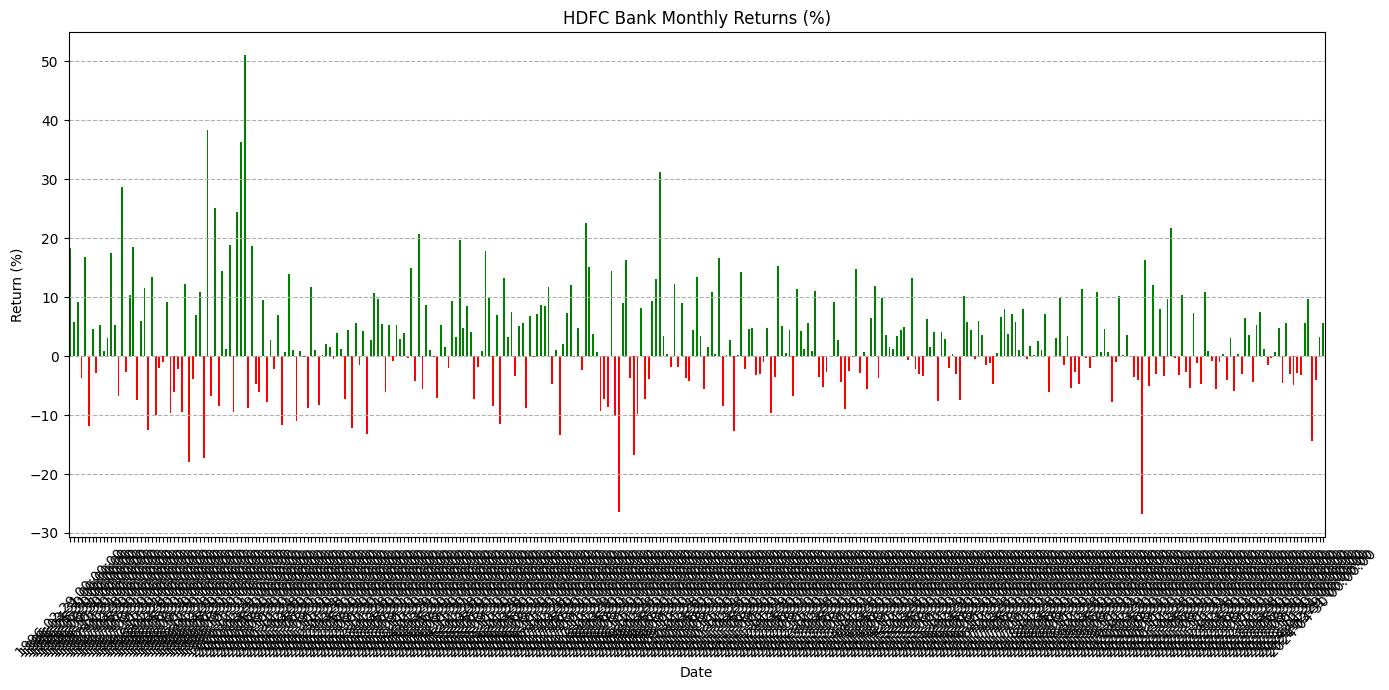

In [11]:
# Calculate monthly returns
monthly_returns = df['close'].resample('ME').ffill().pct_change() * 100
monthly_returns = monthly_returns.dropna()

plt.figure(figsize=(14, 7))
monthly_returns.plot(kind='bar', color=np.where(monthly_returns > 0, 'green', 'red'))
plt.title('HDFC Bank Monthly Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Volatility and Risk Section (Rolling Volatility Chart)

We will calculate and plot the rolling volatility (standard deviation of daily returns) to assess the stock's risk over time.

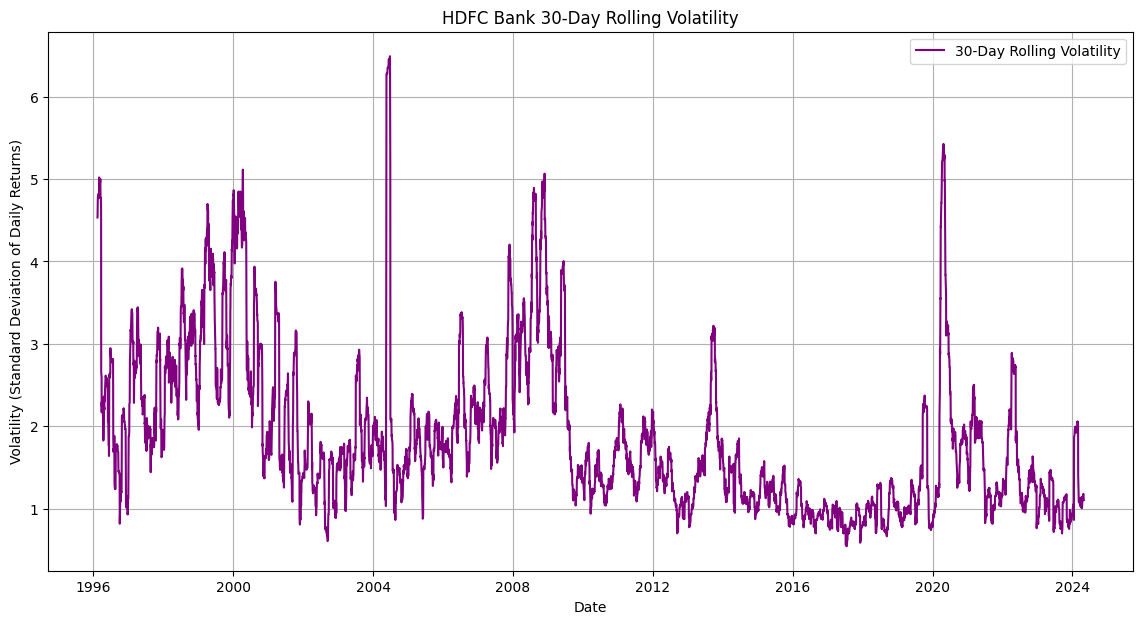

In [9]:
# Calculate 30-day Rolling Volatility (standard deviation of daily returns)
df['Volatility'] = df['Daily_Return'].rolling(window=30).std()

# Plotting the Rolling Volatility
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Volatility'], label='30-Day Rolling Volatility', color='purple')
plt.title('HDFC Bank 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.grid(True)
plt.legend()
plt.show()

### 6. High vs Low Price Analysis (Area Chart)

We will create an area chart to visualize the daily high and low prices, showing the trading range for the stock over time.

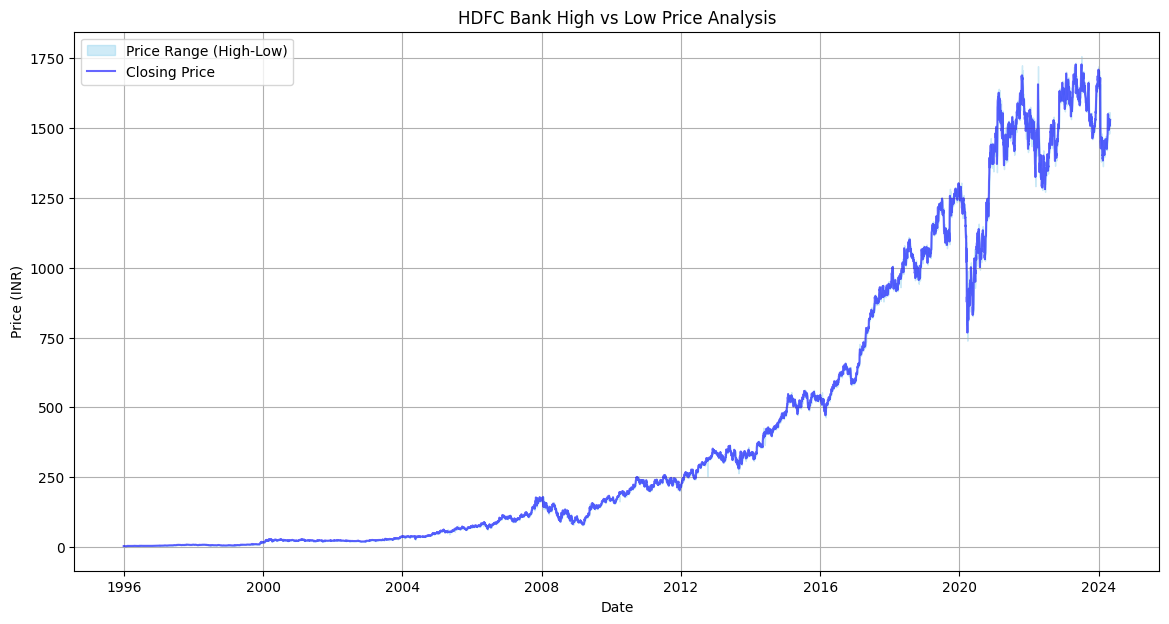

In [10]:
plt.figure(figsize=(14, 7))
plt.fill_between(df.index, df['low'], df['high'], color='skyblue', alpha=0.4, label='Price Range (High-Low)')
plt.plot(df.index, df['close'], color='blue', alpha=0.6, label='Closing Price')
plt.title('HDFC Bank High vs Low Price Analysis')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.legend()
plt.show()

### 7. Trading Volume Insights

We will identify the highest and lowest trading volume days to understand significant activity periods.

Highest Volume Day: 2017-02-17 with Volume: 201129980.00
Lowest Volume Day: 1996-01-26 with Volume: 0.00


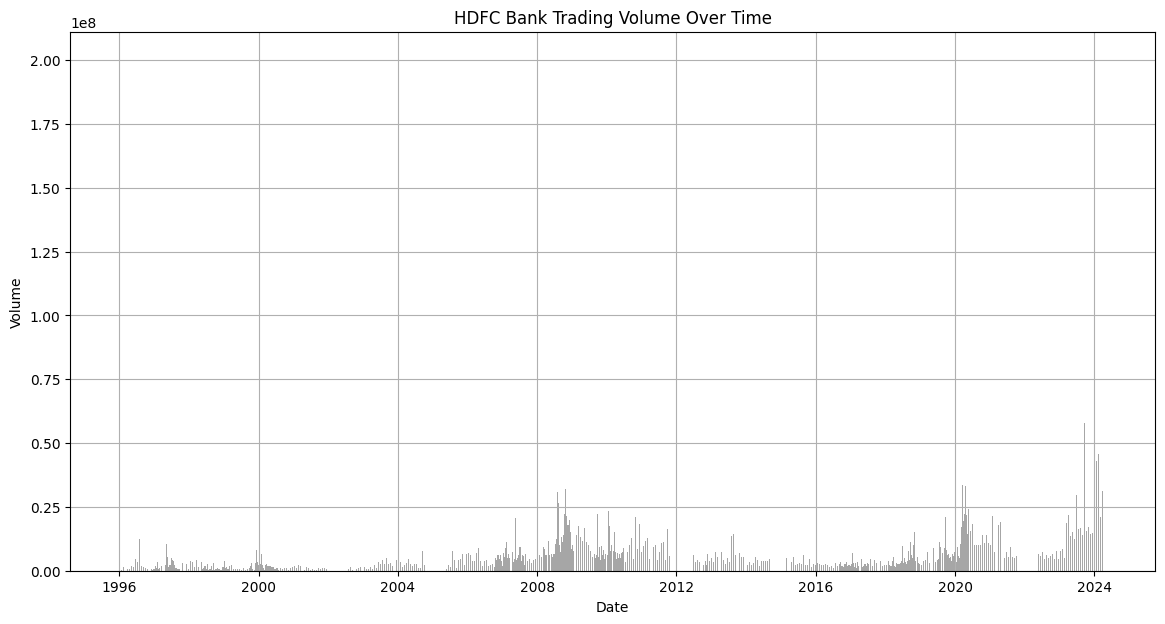

In [12]:
# Highest Volume Day
highest_volume_day = df.loc[df['volume'].idxmax()]
print(f"Highest Volume Day: {highest_volume_day.name.strftime('%Y-%m-%d')} with Volume: {highest_volume_day['volume']:.2f}")

# Lowest Volume Day
lowest_volume_day = df.loc[df['volume'].idxmin()]
print(f"Lowest Volume Day: {lowest_volume_day.name.strftime('%Y-%m-%d')} with Volume: {lowest_volume_day['volume']:.2f}")

# Plotting Trading Volume over time
plt.figure(figsize=(14, 7))
plt.bar(df.index, df['volume'], color='gray', alpha=0.7)
plt.title('HDFC Bank Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

### 9. Stock Return Calculator

This section provides a calculator to determine the profit/loss and Return on Investment (ROI) based on a selected date range and investment amount.

In [13]:
def calculate_returns(start_date_str, end_date_str, investment_amount):
    try:
        start_date = pd.to_datetime(start_date_str)
        end_date = pd.to_datetime(end_date_str)
    except ValueError:
        print("Error: Invalid date format. Please use YYYY-MM-DD.")
        return

    # Filter data for the specified date range
    filtered_df = df.loc[start_date:end_date]

    if filtered_df.empty:
        print(f"No data available for the selected date range: {start_date_str} to {end_date_str}.")
        return

    # Get the closing price on the start and end dates
    # Use .iloc[0] and .iloc[-1] to get the first and last available prices within the range
    buy_price = filtered_df['close'].iloc[0]
    sell_price = filtered_df['close'].iloc[-1]

    if buy_price == 0:
        print("Error: Buy price is zero, cannot calculate returns.")
        return

    # Calculate number of shares bought
    shares_bought = investment_amount / buy_price

    # Calculate final value of investment
    final_value = shares_bought * sell_price

    # Calculate profit/loss
    profit_loss = final_value - investment_amount

    # Calculate ROI in percentage
    roi_percent = (profit_loss / investment_amount) * 100

    print(f"Investment Start Date: {start_date.strftime('%Y-%m-%d')}")
    print(f"Investment End Date: {end_date.strftime('%Y-%m-%d')}")
    print(f"Initial Investment: INR {investment_amount:.2f}")
    print(f"Buy Price (on {filtered_df.index[0].strftime('%Y-%m-%d')}): INR {buy_price:.2f}")
    print(f"Sell Price (on {filtered_df.index[-1].strftime('%Y-%m-%d')}): INR {sell_price:.2f}")
    print(f"Shares Purchased: {shares_bought:.2f}")
    print(f"Final Value: INR {final_value:.2f}")
    print(f"Profit/Loss: INR {profit_loss:.2f}")
    print(f"ROI: {roi_percent:.2f}%")

# Example Usage:
# You can change these dates and investment amount
start_date_example = '2023-01-01'
end_date_example = '2024-01-01'
investment_example = 100000 # INR 1 Lakh

print("\n--- Example Stock Return Calculation ---")
calculate_returns(start_date_example, end_date_example, investment_example)

start_date_example_2 = '2020-03-01'
end_date_example_2 = '2020-09-01'
investment_example_2 = 50000 # INR 50,000

print("\n--- Another Example Stock Return Calculation ---")
calculate_returns(start_date_example_2, end_date_example_2, investment_example_2)


--- Example Stock Return Calculation ---
Investment Start Date: 2023-01-01
Investment End Date: 2024-01-01
Initial Investment: INR 100000.00
Buy Price (on 2023-01-02): INR 1628.70
Sell Price (on 2024-01-01): INR 1698.10
Shares Purchased: 61.40
Final Value: INR 104261.07
Profit/Loss: INR 4261.07
ROI: 4.26%

--- Another Example Stock Return Calculation ---
Investment Start Date: 2020-03-01
Investment End Date: 2020-09-01
Initial Investment: INR 50000.00
Buy Price (on 2020-03-02): INR 1179.60
Sell Price (on 2020-09-01): INR 1127.30
Shares Purchased: 42.39
Final Value: INR 47783.15
Profit/Loss: INR -2216.85
ROI: -4.43%


### 10. Dashboard Filters

This section provides interactive filters to refine the data displayed in the dashboard components. You can filter by a specific date range, year, month, or quarter to analyze HDFC Bank's stock performance under various conditions.

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

def create_filtered_dashboard(start_date, end_date, selected_year, selected_month, selected_quarter):
    clear_output(wait=True)
    display(widgets.HBox([date_range_picker_widget, year_selector, month_selector, quarter_selector]))

    filtered_df = df.copy()

    # Apply date range filter first
    if start_date is not None and end_date is not None:
        filtered_df = filtered_df.loc[start_date:end_date]

    # Apply year filter
    if selected_year != 'All':
        filtered_df = filtered_df[filtered_df['Year'] == selected_year]

    # Apply month filter
    if selected_month != 'All':
        filtered_df = filtered_df[filtered_df['Month'] == selected_month]

    # Apply quarter filter
    if selected_quarter != 'All':
        filtered_df = filtered_df[filtered_df['Quarter'] == selected_quarter]

    if filtered_df.empty:
        print("No data available for the selected filters.")
        return

    print("### Filtered HDFC Bank Stock Dashboard ###\n")

    # --- 1. Stock Performance Overview (KPI Cards) ---
    print("**1. Stock Performance Overview (KPI Cards)**")
    current_price_filtered = filtered_df['close'].iloc[-1]

    # Calculate 52-week high/low within the filtered data. Adjust window if filtered data is less than 252 days.
    if len(filtered_df) >= 252:
        df_last_52_weeks_filtered = filtered_df['close'].iloc[-252:]
        week_high_52_filtered = df_last_52_weeks_filtered.max()
        week_low_52_filtered = df_last_52_weeks_filtered.min()
    else:
        week_high_52_filtered = filtered_df['close'].max()
        week_low_52_filtered = filtered_df['close'].min()

    market_trend_percent_filtered = filtered_df['Daily_Return'].iloc[-1] if not filtered_df['Daily_Return'].isnull().all() else 0.0

    # Create HTML for KPI cards
    kpi_html = f"""
    <div style='display: flex; justify-content: space-around; flex-wrap: wrap; margin-bottom: 20px;'>
        <div style='background-color: #f0f8ff; border: 1px solid #add8e6; border-radius: 8px; padding: 15px; margin: 10px; text-align: center; width: 200px;'>
            <h4>Current Price</h4>
            <p style='font-size: 1.5em; font-weight: bold;'>₹{current_price_filtered:.2f}</p>
        </div>
        <div style='background-color: #f0fff0; border: 1px solid #90ee90; border-radius: 8px; padding: 15px; margin: 10px; text-align: center; width: 200px;'>
            <h4>High (Filtered Period)</h4>
            <p style='font-size: 1.5em; font-weight: bold;'>₹{week_high_52_filtered:.2f}</p>
        </div>
        <div style='background-color: #fff0f5; border: 1px solid #ffb6c1; border-radius: 8px; padding: 15px; margin: 10px; text-align: center; width: 200px;'>
            <h4>Low (Filtered Period)</h4>
            <p style='font-size: 1.5em; font-weight: bold;'>₹{week_low_52_filtered:.2f}</p>
        </div>
        <div style='background-color: #fffacd; border: 1px solid #ffd700; border-radius: 8px; padding: 15px; margin: 10px; text-align: center; width: 200px;'>
            <h4>Market Trend (Last Day)</h4>
            <p style='font-size: 1.5em; font-weight: bold; color: {'green' if market_trend_percent_filtered >= 0 else 'red'};'>{market_trend_percent_filtered:.2f}%</p>
        </div>
    </div>
    """
    display(HTML(kpi_html))

    # --- 2. Price Movement Charts (Line Chart) & 3. Moving Average Analysis for 365 days ---
    print("**2 & 3. Price Movement (Line Chart for Closing Price) and Moving Average Analysis**")
    fig, axes = plt.subplots(1, 2, figsize=(20, 6)) # Create two subplots side-by-side

    # Plot 1: Closing Price Line Chart
    axes[0].plot(filtered_df.index, filtered_df['close'], label='Closing Price', color='blue')
    axes[0].set_title('HDFC Bank Stock Price Movement (Filtered)')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Closing Price (INR)')
    axes[0].grid(True)
    axes[0].legend()

    # Plot 2: Moving Average Analysis
    if len(filtered_df) >= 365:
        filtered_df['SMA_365'] = filtered_df['close'].rolling(window=365).mean()
        axes[1].plot(filtered_df.index, filtered_df['close'], label='Closing Price', color='blue', alpha=0.7)
        axes[1].plot(filtered_df.index, filtered_df['SMA_365'], label='365-Day SMA', color='red', linestyle='--')
        axes[1].set_title('HDFC Bank Stock Price with 365-Day Moving Average (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Price (INR)')
        axes[1].grid(True)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'Not enough data for 365-day SMA', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('365-Day Moving Average (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Price (INR)')
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Candlestick chart requires mplfinance and specific data structure,
    # and can be too dense for interactive filtering if not carefully managed.
    # Keeping it separate or adding as an optional plot is better for dynamic dashboards.
    # For this consolidated view, we'll focus on the line chart for simplicity.

    # --- 4. Monthly Return Analysis in % & 5. Volatility and Risk Section (Rolling Volatility Chart) ---
    print("\n**4 & 5. Monthly Return Analysis (%) and Volatility and Risk (Rolling Volatility Chart)**")
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Plot 1: Monthly Return Analysis
    monthly_returns_filtered = filtered_df['close'].resample('ME').ffill().pct_change() * 100
    monthly_returns_filtered = monthly_returns_filtered.dropna()

    if not monthly_returns_filtered.empty:
        monthly_returns_filtered.plot(kind='bar', color=np.where(monthly_returns_filtered > 0, 'green', 'red'), ax=axes[0])
        axes[0].set_title('HDFC Bank Monthly Returns (%) (Filtered)')
        axes[0].set_xlabel('Date')
        axes[0].set_ylabel('Return (%)')
        axes[0].grid(axis='y', linestyle='--')
        axes[0].tick_params(axis='x', rotation=45)
    else:
        axes[0].text(0.5, 0.5, 'No monthly returns data available for the filtered period.', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)
        axes[0].set_title('HDFC Bank Monthly Returns (%) (Filtered)')
        axes[0].set_xlabel('Date')
        axes[0].set_ylabel('Return (%)')
        axes[0].grid(axis='y', linestyle='--')

    # Plot 2: Volatility and Risk Section
    if len(filtered_df) >= 30:
        filtered_df['Volatility'] = filtered_df['Daily_Return'].rolling(window=30).std()
        axes[1].plot(filtered_df.index, filtered_df['Volatility'], label='30-Day Rolling Volatility', color='purple')
        axes[1].set_title('HDFC Bank 30-Day Rolling Volatility (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Volatility (Standard Deviation of Daily Returns)')
        axes[1].grid(True)
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'Not enough data in the filtered period to calculate 30-day Rolling Volatility.', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('HDFC Bank 30-Day Rolling Volatility (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Volatility (Standard Deviation of Daily Returns)')
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # --- 6. High vs Low Price Analysis (Area Chart) & 7. Trading Volume Insights ---
    print("\n**6 & 7. High vs Low Price Analysis (Area Chart) and Trading Volume Insights**")
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Plot 1: High vs Low Price Analysis
    axes[0].fill_between(filtered_df.index, filtered_df['low'], filtered_df['high'], color='skyblue', alpha=0.4, label='Price Range (High-Low)')
    axes[0].plot(filtered_df.index, filtered_df['close'], color='blue', alpha=0.6, label='Closing Price')
    axes[0].set_title('HDFC Bank High vs Low Price Analysis (Filtered)')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Price (INR)')
    axes[0].grid(True)
    axes[0].legend()

    # Plot 2: Trading Volume Insights
    if not filtered_df.empty and 'volume' in filtered_df.columns:
        highest_volume_day_filtered = filtered_df.loc[filtered_df['volume'].idxmax()]
        lowest_volume_day_filtered = filtered_df.loc[filtered_df['volume'].idxmin()]
        print(f"Highest Volume Day in Filtered Period: {highest_volume_day_filtered.name.strftime('%Y-%m-%d')} with Volume: {highest_volume_day_filtered['volume']:.2f}")
        print(f"Lowest Volume Day in Filtered Period: {lowest_volume_day_filtered.name.strftime('%Y-%m-%d')} with Volume: {lowest_volume_day_filtered['volume']:.2f}")
        axes[1].bar(filtered_df.index, filtered_df['volume'], color='gray', alpha=0.7)
        axes[1].set_title('HDFC Bank Trading Volume Over Time (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Volume')
        axes[1].grid(True)
    else:
        axes[1].text(0.5, 0.5, 'No volume data available for the filtered period.', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('HDFC Bank Trading Volume Over Time (Filtered)')
        axes[1].set_xlabel('Date')
        axes[1].set_ylabel('Volume')
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# Get unique years, months, and quarters for dropdowns
years = ['All'] + sorted(df['Year'].unique().tolist())
months = ['All'] + sorted(df['Month'].unique().tolist())
quarters = ['All'] + sorted(df['Quarter'].unique().tolist())

# Create widgets
date_range_picker_start = widgets.DatePicker(description='Start Date')
date_range_picker_start.value = df.index.min().date()
date_range_picker_end = widgets.DatePicker(description='End Date')
date_range_picker_end.value = df.index.max().date()

year_selector = widgets.Dropdown(options=years, value='All', description='Year:')
month_selector = widgets.Dropdown(options=months, value='All', description='Month:')
quarter_selector = widgets.Dropdown(options=quarters, value='All', description='Quarter:')

# Combine date pickers into a single HBox for display
date_range_picker_widget = widgets.HBox([widgets.Label('Date Range:'), date_range_picker_start, date_range_picker_end])

# Use interactive_output to link widgets to the function
interactive_output = widgets.interactive_output(create_filtered_dashboard,
                                                {'start_date': date_range_picker_start,
                                                 'end_date': date_range_picker_end,
                                                 'selected_year': year_selector,
                                                 'selected_month': month_selector,
                                                 'selected_quarter': quarter_selector})

# Display widgets and output
display(widgets.VBox([date_range_picker_widget, widgets.HBox([year_selector, month_selector, quarter_selector]), interactive_output]))